In [3]:
%%file loopback_constant.py

import time
import numpy as np

from acadia.data import DataManager
from acadia.runtime import Runtime

class LoopbackConstantRuntime(Runtime):
    
    @classmethod
    def main(cls, mgr: DataManager) -> None:
        from acadia.system import Acadia, StreamConfiguration
        from acadia.channel import Channel
        from acadia.arrays import ProceduralWaveform,ConstantWaveform
        from acadia.data import ArrayRecordGroup
        
        acadia = Acadia()

        pulse_channel = acadia.DAC(1)

        pulse = ConstantWaveform(pulse_channel, length=500e-9)

        capture_channel = acadia.ADC(1)
        capture_data = ProceduralWaveform(capture_channel, generator=None, length=5000e-9, region=acadia.PLDDR0Array)
        capture_configuration = StreamConfiguration(capture_channel, acadia=acadia)
            
        SHOTS = 1000
            
        # We'll collect the data traces in a record group
        traces = ArrayRecordGroup((len(capture_data),), 
                                SHOTS, 
                                dtype=np.complex64, 
                                record_axes=[capture_data.axis()])

        # Create a sequence for the sequencer
        def sequence(a):
            capture_configuration.reset()
            for i in range(20):
                a.sequencer().nop()
            
            with a.channel_synchronizer(block=False):
                a.capture(capture_configuration, capture_data)
                a.generate(pulse)
                a.generate(pulse)
                a.generate(pulse)

        acadia.attach()
        pulse.populate(0.99)

        pulse_channel.set_nyquist_zone(2)
        pulse_channel.configure_nco(frequency=2000e6)
        pulse_channel.set_vop(20000)
        
        capture_channel.set_nyquist_zone(2)
        capture_channel.set_dsa(0)

        acadia.configure_stream(capture_configuration)
        acadia.compile(sequence)
            
        def last_record(data):
            return {"records": np.array([np.max(data["records"], axis=0)]), "axis0": data["axis0"]}

        mgr.add_group("traces", traces, preprocessor=last_record)
    
        for shot in mgr.iterator_progress(range(SHOTS)):
            acadia.run(assemble=(shot==0), block=False)
            trace = Channel.from_samples(capture_data.memory())
            mgr.append("traces", trace)
            
        
    def plot(self):
        import matplotlib.pyplot as plt
        import matplotlib.style as style
        import time
        import numpy as np
        
        from acadia.data import DataManager
        
        style.use(["dark_background"])
        
        fig,ax = plt.subplots(figsize=(8,4))
        (line_re,) = ax.plot([], [])
        (line_im,) = ax.plot([], [])
        
        
        def init():
            ax.set_ylim(-0.01, 0.01)
            ax.set_xlim(0,5)
            ax.grid()
            return line_re, line_im
        
        def update(address, frame):
            traces = DataManager.receive_group("traces", address)
            
            if traces is not None:
                # Just plot only the most recently received trace
                axis = traces.axis()*1e6
                trace = traces.data()[-1,:]
                
                # Update the data (not calling `plot`)
                line_re.set_data(axis, np.real(trace))
                line_im.set_data(axis, np.imag(trace))

            return line_re, line_im
        
        return fig, init, update

Overwriting loopback_constant.py


/home/billy/acadia/pyacadia/acadia/runtime.py:99: UserWarning: frames=functools.partial(<function Runtime._progress_generator at 0x7fcf2e5bddc0>, stop_event=<threading.Event object at 0x7fcf56920cd0>, address=('192.168.2.69', 6672)) which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  self._anim = FuncAnimation(fig,


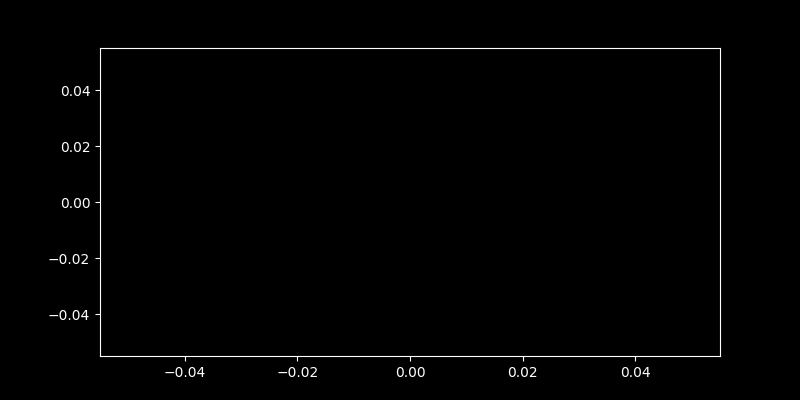

  0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
%matplotlib widget
from loopback_constant import LoopbackConstantRuntime
# import logging
# logging.basicConfig(level=logging.DEBUG)
rt = LoopbackConstantRuntime("192.168.2.69", "loopback_constant.py")
rt.run()

In [6]:
rt.stop()

updated


In [4]:
print(rt._proc.stdout.read().decode("ascii"))

metal: debug:     added page size 4096 @/tmp
metal: debug:     registered platform bus
metal: debug:     registered pci bus
metal: info:      Registered shmem provider linux_shm.
metal: debug:     metal_ion_shm_provider_init: successfully initialze ion shm provider.
metal: info:      Registered shmem provider ion.reserved.
metal: info:      Registered shmem provider ion.ion_system_contig_heap.
metal: info:      Registered shmem provider ion.ion_system_heap.
metal: info:      metal_linux_dev_open: checking driver vfio-platform,1000700000.usp_rf_data_converter,uio_pdrv_genirq
metal: info:      metal_linux_dev_open: checking driver uio_pdrv_genirq,1000700000.usp_rf_data_converter,uio_pdrv_genirq
metal: info:      metal_linux_dev_open: driver uio_pdrv_genirq bound to 1000700000.usp_rf_data_converter
metal: debug:     bound device 1000700000.usp_rf_data_converter to driver uio_pdrv_genirq
metal: debug:     opened platform:1000700000.usp_rf_data_converter as /dev/uio4
metal: warning:   readi